<a href="https://colab.research.google.com/github/IanWilmutF09/Prediksi-Machine-Learning/blob/main/Prediksi-Peningkatan-Suhu-Bumi/Regresi_Anomali_Suhu_Gas_Rumah_Kaca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Preparation**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Path to your file
file_path = '/content/drive/My Drive/Skripsi Yosef GH Drive/data_anomali_temperatur_ready.csv'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the file using pandas (for CSV files)
df = pd.read_csv(file_path)

# Display the first few rows of the dataframe
print(df.head())

Mounted at /content/drive
   Year  Month  Anomaly-Monthly  Unc-Monthly  Anomaly-Annual  Unc-Annual  \
0  1850      1           -0.790        0.404             NaN         NaN   
1  1850      2           -0.243        0.524             NaN         NaN   
2  1850      3           -0.394        0.449             NaN         NaN   
3  1850      4           -0.625        0.304             NaN         NaN   
4  1850      5           -0.652        0.249             NaN         NaN   

   Anomaly-Five-Year  Unc-Five-Year  Anomaly-Ten-Year  Unc-Ten-Year  \
0                NaN            NaN               NaN           NaN   
1                NaN            NaN               NaN           NaN   
2                NaN            NaN               NaN           NaN   
3                NaN            NaN               NaN           NaN   
4                NaN            NaN               NaN           NaN   

   Anomaly-Twenty-Year  Unc-Twenty-Year  
0                  NaN              NaN  
1     

In [ ]:
# Menggabungkan kolom 'Year' dan 'Month' menjadi kolom 'time'
df['time'] = df['Year'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2)

# Konversi kolom 'time' menjadi datetime
df['time'] = pd.to_datetime(df['time'], format='%Y-%m')

# Memilih hanya kolom 'time' dan 'Anomaly-Monthly'
df = df[['time', 'Anomaly-Monthly']]

# Memfilter data dari tahun 1950 sampai 2021
df = df[(df['time'].dt.year >= 1950) & (df['time'].dt.year <= 2021)]

# Mengelompokkan berdasarkan tahun dan menghitung rata-rata setiap tahun
df['Year'] = df['time'].dt.year
annual_df = df.groupby('Year')['Anomaly-Monthly'].mean().reset_index()

# Menampilkan DataFrame tahunan
print(annual_df)

    Year  Anomaly-Monthly
0   1950        -0.171833
1   1951         0.009250
2   1952         0.080417
3   1953         0.154333
4   1954        -0.041417
..   ...              ...
67  2017         0.963333
68  2018         0.890167
69  2019         1.026333
70  2020         1.052417
71  2021         0.897417

[72 rows x 2 columns]


# **Data Preparation: Annual Gas Emission of NO, CH4 and CO2**

In [ ]:
# Path to your file
file_path_2 = '/content/drive/My Drive/Skripsi Yosef GH Drive/Annual Gas Ready.csv'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the file using pandas (for CSV files)
df_gas = pd.read_csv(file_path_2)

# Display the first few rows of the dataframe
print(df_gas.head())

   Year  Annual NO  Annual CH4  Annual CO2
0  1850  147522530  1239386900  2616430800
1  1851  150177400  1244030200  2706513700
2  1852  152773860  1250666800  2753426400
3  1853  155275760  1258164700  2820414000
4  1854  157646990  1270659800  2880645400


# **Regression: NO, CH4 and CO2**

Regression results for Annual NO:
                            OLS Regression Results                            
Dep. Variable:        Anomaly-Monthly   R-squared:                       0.780
Model:                            OLS   Adj. R-squared:                  0.777
Method:                 Least Squares   F-statistic:                     248.0
Date:                Thu, 11 Jul 2024   Prob (F-statistic):           1.05e-24
Time:                        00:37:40   Log-Likelihood:                 28.623
No. Observations:                  72   AIC:                            -53.25
Df Residuals:                      70   BIC:                            -48.69
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.8

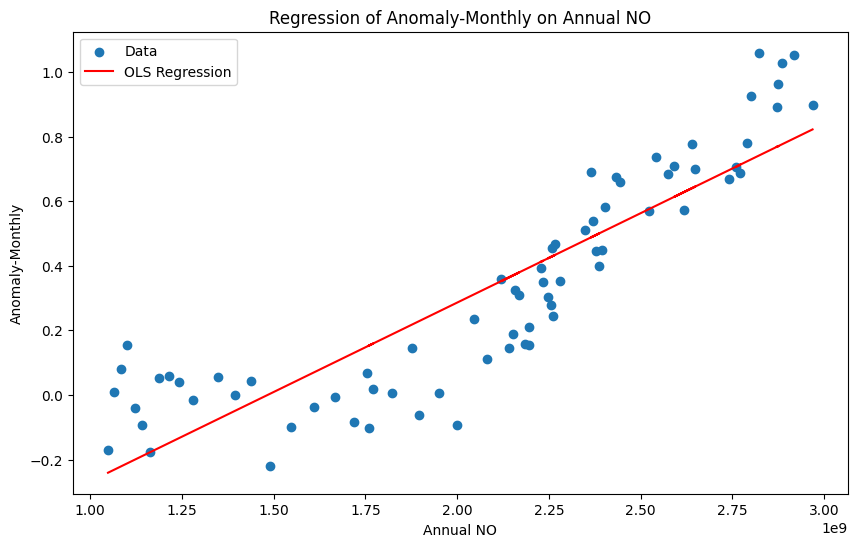

The regression for Annual NO is significant (p-value: 0.0000)

Regression results for Annual CH4:
                            OLS Regression Results                            
Dep. Variable:        Anomaly-Monthly   R-squared:                       0.812
Model:                            OLS   Adj. R-squared:                  0.809
Method:                 Least Squares   F-statistic:                     301.9
Date:                Thu, 11 Jul 2024   Prob (F-statistic):           4.32e-27
Time:                        00:37:40   Log-Likelihood:                 34.258
No. Observations:                  72   AIC:                            -64.52
Df Residuals:                      70   BIC:                            -59.96
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------

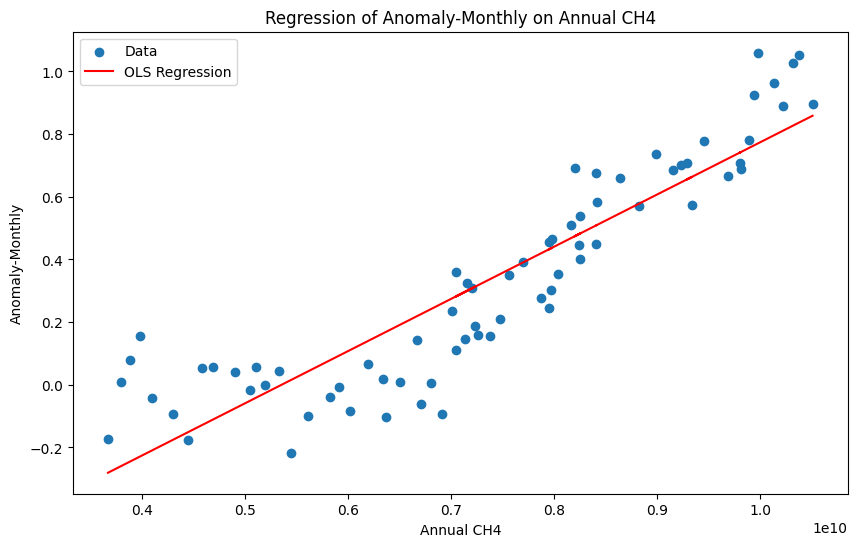

The regression for Annual CH4 is significant (p-value: 0.0000)

Regression results for Annual CO2:
                            OLS Regression Results                            
Dep. Variable:        Anomaly-Monthly   R-squared:                       0.878
Model:                            OLS   Adj. R-squared:                  0.876
Method:                 Least Squares   F-statistic:                     503.3
Date:                Thu, 11 Jul 2024   Prob (F-statistic):           1.10e-33
Time:                        00:37:40   Log-Likelihood:                 49.840
No. Observations:                  72   AIC:                            -95.68
Df Residuals:                      70   BIC:                            -91.13
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------

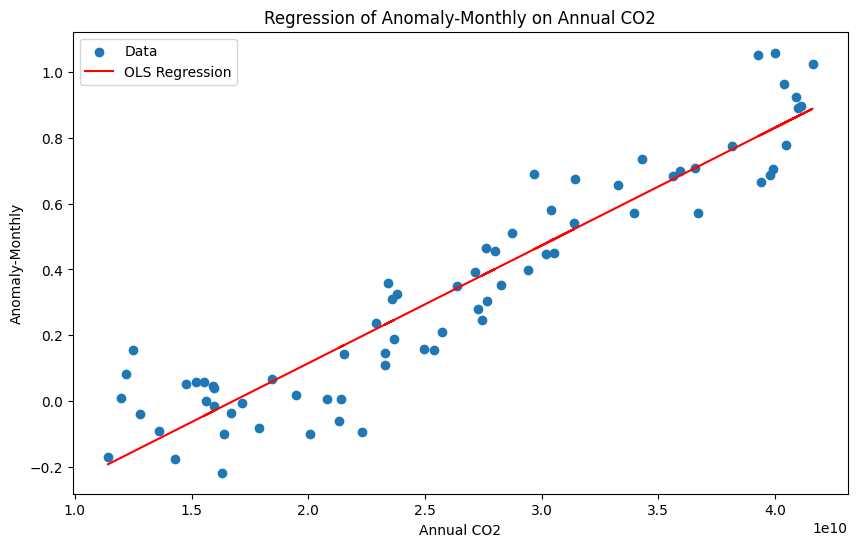

The regression for Annual CO2 is significant (p-value: 0.0000)



In [ ]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Assuming annual_df and df_gas are already defined and have the required data
# Merge the two dataframes on the 'Year' column
merged_df = pd.merge(annual_df, df_gas, on='Year')

# Define the independent variable (X) and dependent variable (Y) for each regression
X_columns = ['Annual NO', 'Annual CH4', 'Annual CO2']
Y_column = 'Anomaly-Monthly'

# Iterate over each column in X_columns to perform regression
for X_column in X_columns:
    X = merged_df[[X_column]]
    Y = merged_df[Y_column]

    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Perform the regression
    model = sm.OLS(Y, X).fit()

    # Print the regression summary
    print(f"Regression results for {X_column}:")
    print(model.summary())

    # Plot the regression results
    plt.figure(figsize=(10, 6))
    plt.scatter(merged_df[X_column], merged_df[Y_column], label='Data')
    plt.plot(merged_df[X_column], model.predict(X), color='red', label='OLS Regression')
    plt.xlabel(X_column)
    plt.ylabel(Y_column)
    plt.title(f'Regression of {Y_column} on {X_column}')
    plt.legend()
    plt.show()

    # Check if the regression is significant based on the p-value of the slope
    if model.pvalues[1] < 0.05:  # p-value of the slope (not the intercept)
        print(f"The regression for {X_column} is significant (p-value: {model.pvalues[1]:.4f})\n")
    else:
        print(f"The regression for {X_column} is not significant (p-value: {model.pvalues[1]:.4f})\n")

# **Data Preparation: Annual Emission of F Gas**

In [ ]:
# Path to your file
file_path_3 = '/content/drive/My Drive/Skripsi Yosef GH Drive/Annual F Gas Ready.xlsx'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the file using pandas (for CSV files)
df_F_gas = pd.read_excel(file_path_3)

# Display the first few rows of the dataframe
print(df_F_gas.head())

   Year   Annual F Gas
0  1950  788698.882329
1  1951  833578.959385
2  1952  882068.628284
3  1953  934549.038969
4  1954  990221.825278


# **1950 - 2022 Anomaly-Temperature**

In [ ]:
# Memfilter data dari tahun 1950 sampai 2022
df = df[(df['time'].dt.year >= 1950) & (df['time'].dt.year <= 2022)]

# Mengelompokkan berdasarkan tahun dan menghitung rata-rata setiap tahun
df['Year'] = df['time'].dt.year
annual_df_1950_Onward = df.groupby('Year')['Anomaly-Monthly'].mean().reset_index()

# Menampilkan DataFrame tahunan
print(annual_df_1950_Onward)

    Year  Anomaly-Monthly
0   1950        -0.171833
1   1951         0.009250
2   1952         0.080417
3   1953         0.154333
4   1954        -0.041417
..   ...              ...
67  2017         0.963333
68  2018         0.890167
69  2019         1.026333
70  2020         1.052417
71  2021         0.897417

[72 rows x 2 columns]


# **Regression: F Gas**

Regression results for Annual F Gas:
                            OLS Regression Results                            
Dep. Variable:        Anomaly-Monthly   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                     457.2
Date:                Thu, 11 Jul 2024   Prob (F-statistic):           2.07e-32
Time:                        00:37:42   Log-Likelihood:                 46.821
No. Observations:                  72   AIC:                            -89.64
Df Residuals:                      70   BIC:                            -85.09
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const      

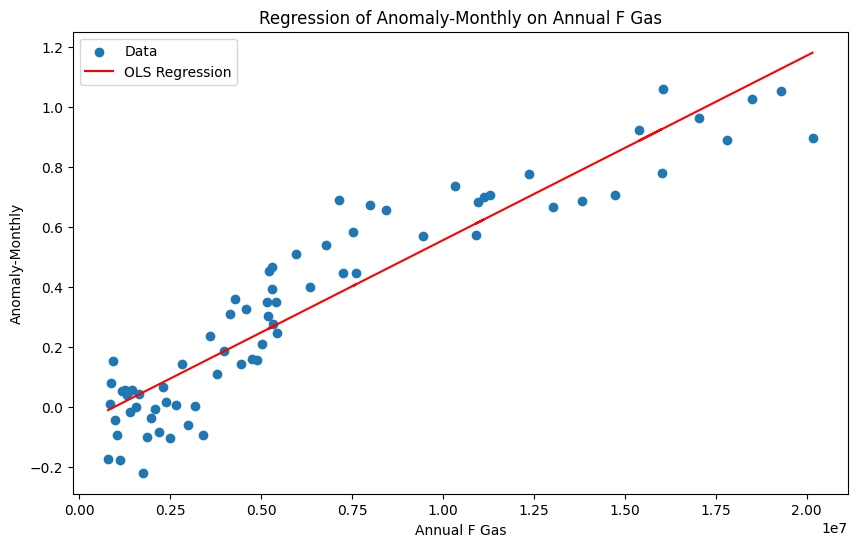

The regression for Annual F Gas is significant (p-value: 0.0000)



In [ ]:
# Assuming annual_df and df_gas are already defined and have the required data
# Merge the two dataframes on the 'Year' column
merged_df = pd.merge(annual_df_1950_Onward, df_F_gas, on='Year')

# Define the independent variable (X) and dependent variable (Y) for each regression
X_columns = ['Annual F Gas']
Y_column = 'Anomaly-Monthly'

# Iterate over each column in X_columns to perform regression
for X_column in X_columns:
    X = merged_df[[X_column]]
    Y = merged_df[Y_column]

    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Perform the regression
    model = sm.OLS(Y, X).fit()

    # Print the regression summary
    print(f"Regression results for {X_column}:")
    print(model.summary())

    # Plot the regression results
    plt.figure(figsize=(10, 6))
    plt.scatter(merged_df[X_column], merged_df[Y_column], label='Data')
    plt.plot(merged_df[X_column], model.predict(X), color='red', label='OLS Regression')
    plt.xlabel(X_column)
    plt.ylabel(Y_column)
    plt.title(f'Regression of {Y_column} on {X_column}')
    plt.legend()
    plt.show()

    # Check if the regression is significant based on the p-value of the slope
    if model.pvalues[1] < 0.05:  # p-value of the slope (not the intercept)
        print(f"The regression for {X_column} is significant (p-value: {model.pvalues[1]:.4f})\n")
    else:
        print(f"The regression for {X_column} is not significant (p-value: {model.pvalues[1]:.4f})\n")